## 神经网络如何看待一只猫

一个在 ImageNet 上预训练的神经网络能够识别多达 1000 种不同类别的物体，比如不同品种的猫。很有趣的是，看看神经网络眼中的**理想暹罗猫**是什么样子。

> 当然，你可以将*暹罗猫*替换为 ImageNet 中的任何其他类别。

首先，让我们加载 VGG 网络：


In [3]:
import torchvision
import torch
model=torchvision.models.vgg16(weights=None)
weight_root="../vgg16-397923af (1).pth"
model.load_state_dict(torch.load(weight_root))


<All keys matched successfully>

In [2]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from PIL import Image
import json
np.set_printoptions(precision=3,suppress=True)
#打印设置，保留三位小数，抑制科学计数法

classes = json.loads(open('imagenet_classes.json','r').read())

2025-11-12 14:05:34.635965: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-12 14:05:34.681201: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-12 14:05:35.819522: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 优化结果

为了呈现理想的猫，我们将从一张随机噪声图像开始，并尝试使用梯度下降优化技术调整图像，使网络能够识别出一只猫。

![优化循环](../../../../../lessons/4-ComputerVision/08-TransferLearning/images/ideal-cat-loop.png)

这是我们的起始图像：


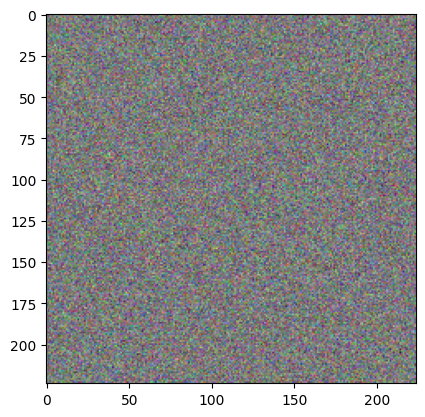

In [10]:
import torch
import matplotlib.pyplot as plt

x = torch.randn((1, 3, 224, 224), requires_grad=True)

def normalize(img):
    return (img - img.min()) / (img.max() - img.min())

pic = normalize(x)

# 去掉 batch 维度
plt.imshow(pic[0].detach().permute(1, 2, 0))
plt.show()

我们使用 `normalize` 函数将我们的值调整到 0-1 范围内。

如果我们在这张图片上调用我们的 VGG 网络，我们将得到一个或多或少随机分布的概率：


Predicted class: 284 (Siamese cat, Siamese)
Probability of predicted class = 1.0000


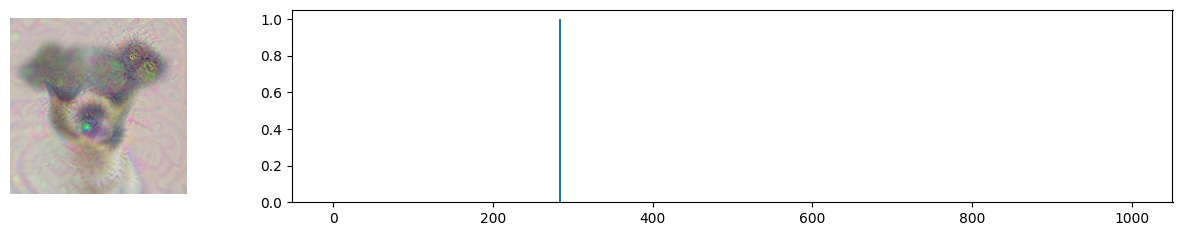

In [14]:
import torch.nn.functional as F

def plot_result(x):
    model.eval()
    # x.to("cuda")
    with torch.no_grad():
        res = model(x)[0]
        probs = F.softmax(res, dim=0)  # 转成概率分布
    
    cls = torch.argmax(probs)
    print(f"Predicted class: {cls} ({classes[cls]})")
    print(f"Probability of predicted class = {probs[cls]:.4f}")
    
    fig, ax = plt.subplots(1, 2, figsize=(15, 2.5), gridspec_kw={"width_ratios": [1, 5]})
    ax[0].imshow(normalize(x[0]).detach().cpu().permute(1, 2, 0))
    ax[0].axis('off')
    ax[1].bar(range(len(probs)), probs.cpu(), width=3)
    plt.show()
plot_result(x)

尽管看起来某个类别的概率比其他类别高得多，但实际上它仍然很低——查看刻度可以发现实际概率仍然在5%左右。

现在我们选择一个目标类别（例如，**暹罗猫**），并开始使用梯度下降来调整图像。如果 $x$ 是输入图像，$V$ 是 VGG 网络，我们将计算损失函数 $\mathcal{L} = \mathcal{L}(c,V(x))$（其中 $c$ 是目标类别），并使用以下公式调整 $x$：
$$
x^{(i+1)} = x^{(i)} - \eta{\partial \mathcal{L}\over\partial x}
$$
损失函数将使用交叉熵损失，因为我们在比较两个概率分布。在我们的例子中，由于类别是用数字表示的，而不是用独热编码向量表示的，我们将使用*稀疏分类交叉熵*。

我们将重复这个过程若干个周期，并在过程中打印图像。

> 最好在支持 GPU 的计算设备上运行这段代码，或者减少周期数以缩短等待时间。


In [ ]:


import torch
target = torch.tensor([284]) # Siamese cat
def optimize(x,target,epochs=1000,show_every=None,loss_fn=torch.nn.CrossEntropyLoss(), eta=1.0):
    if show_every is None:
        show_every = epochs // 50
    for i in range(epochs):
        print(i)
        outputs=model(x)
        loss=loss_fn(outputs,target)
        loss.backward()
        grads=x.grad
        with torch.no_grad():
            x-=eta*grads
            if i%show_every == 0:
                clear_output(wait=True)
                print(f"Epoch: {i}, loss: {loss}")
                plt.imshow(normalize(x[0]).detach().cpu().permute(1, 2, 0))
                plt.axis("off")
                plt.show()
        x.grad.zero_()

optimize(x,target)

Predicted class: 284 (Siamese cat, Siamese)
Probability of predicted class = 0.9935


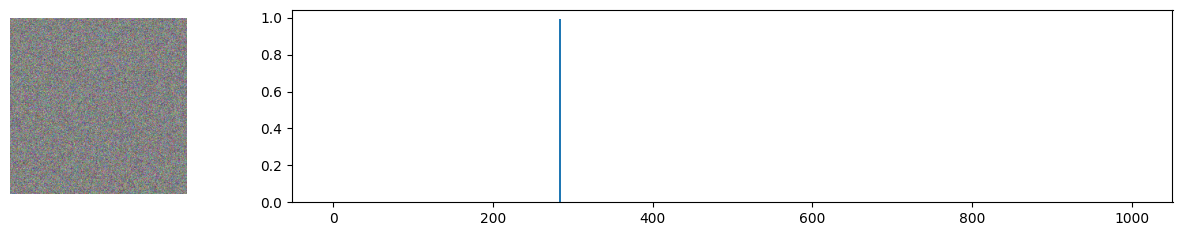

In [20]:
plot_result(x)

我们现在已经为神经网络获得了一张看起来像猫的图像，尽管对我们来说它仍然像是噪声。如果我们再优化一段时间——很可能会得到一张**理想的噪声猫**图像，其概率接近1。

## 理解噪声

这种噪声对我们来说意义不大，但它很可能包含了许多典型于猫的低级滤波器。然而，由于优化输入以获得理想结果的方法非常多，优化算法并没有动力去寻找那些视觉上易于理解的模式。

为了让图像看起来不那么像噪声，我们可以在损失函数中引入一个额外的项——**变化损失**。它衡量图像中相邻像素的相似程度。如果我们将这一项加入到我们的*损失函数*中，它会迫使优化器找到噪声更少的解决方案，从而包含更多可识别的细节。

> 实际操作中，我们需要在交叉熵损失和变化损失之间找到平衡，以获得良好的结果。在我们的函数中，我们引入了一些数值系数，你可以调整这些系数并观察图像的变化。


Epoch 0 loss=770.547


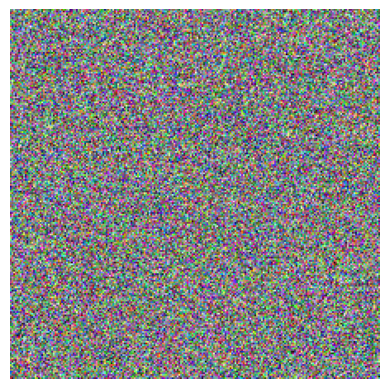

Epoch 100 loss=300.726


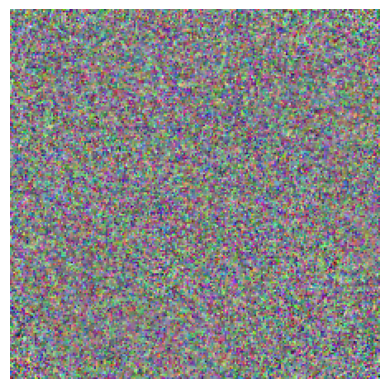

Epoch 200 loss=74.131


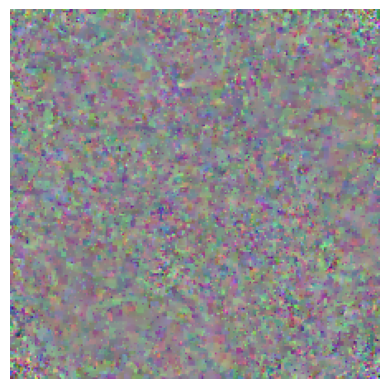

Epoch 300 loss=10.152


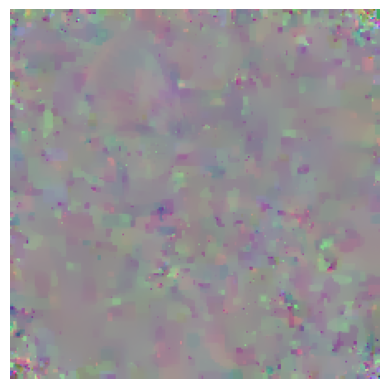

Epoch 400 loss=2.208


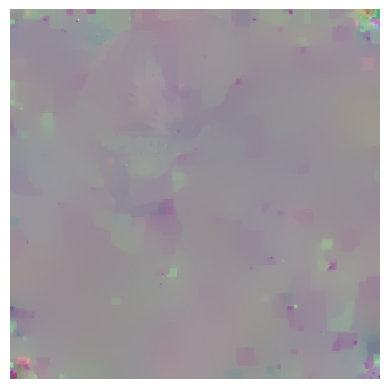

Epoch 500 loss=1.245


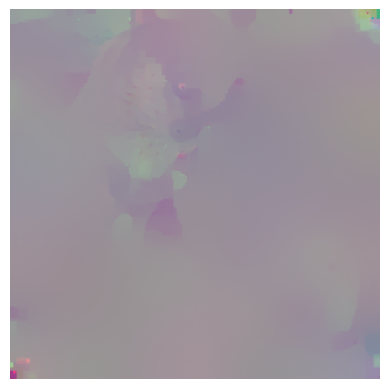

Epoch 600 loss=1.077


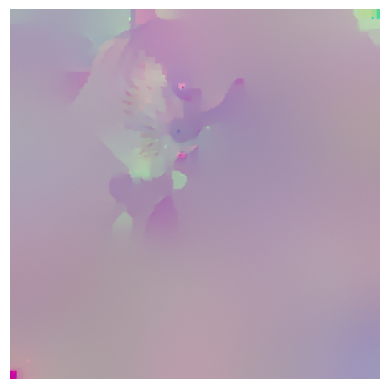

Epoch 700 loss=1.029


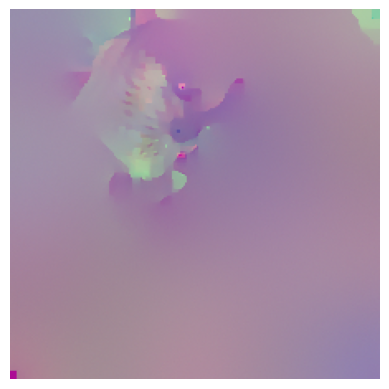

Epoch 800 loss=1.001


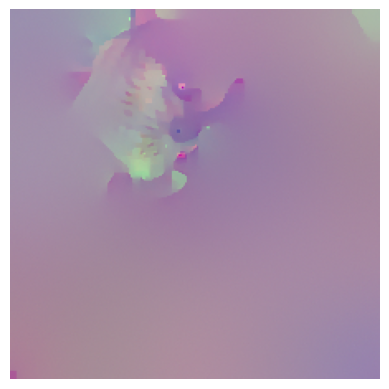

Epoch 900 loss=0.987


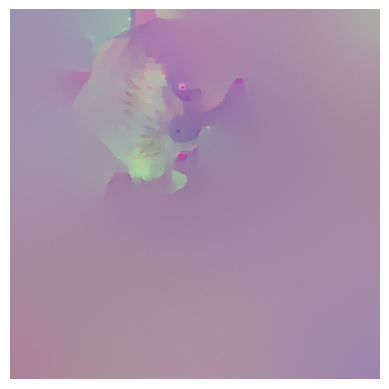

Parameter containing:
tensor([[[[-0.0069, -0.0083, -0.0060,  ...,  0.0156,  0.0172,  0.0141],
          [-0.0061, -0.0114, -0.0086,  ...,  0.0149,  0.0137,  0.0157],
          [-0.0083, -0.0080, -0.0087,  ...,  0.0159,  0.0159,  0.0141],
          ...,
          [ 0.0143,  0.0127,  0.0122,  ..., -0.0063, -0.0037, -0.0016],
          [ 0.0124,  0.0108,  0.0107,  ..., -0.0052, -0.0033, -0.0070],
          [ 0.0116,  0.0127,  0.0109,  ..., -0.0074, -0.0050, -0.0063]],

         [[-0.0270, -0.0282, -0.0266,  ..., -0.0034, -0.0055, -0.0056],
          [-0.0271, -0.0259, -0.0269,  ..., -0.0048, -0.0044, -0.0049],
          [-0.0249, -0.0267, -0.0249,  ..., -0.0032, -0.0036, -0.0048],
          ...,
          [-0.0460, -0.0453, -0.0466,  ..., -0.0484, -0.0487, -0.0480],
          [-0.0458, -0.0491, -0.0461,  ..., -0.0496, -0.0487, -0.0503],
          [-0.0483, -0.0471, -0.0476,  ..., -0.0478, -0.0510, -0.0473]],

         [[ 0.0196,  0.0212,  0.0205,  ...,  0.0080,  0.0091,  0.0091],
        

In [88]:
# def total_variation(x):
#     tv_h = torch.mean((x[:, :, 1:, :] - x[:, :, :-1, :])**2)
#     tv_w = torch.mean((x[:, :, :, 1:] - x[:, :, :, :-1])**2)
#     return tv_h + tv_w
def total_variation(x):
    tv_h = torch.sum(torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]))
    tv_w = torch.sum(torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]))
    return tv_h + tv_w

def total_loss(x, res, target):
    ce = torch.nn.functional.cross_entropy(res, target)
    tv = total_variation(x)
    return 10 * ce + 0.002 * tv  # 建议这个比例

def optimize_visual(x, target, model, epochs=1000, lr=0.01):
    x = torch.nn.Parameter(x)
    optimizer = torch.optim.Adam([x], lr=lr)

    for i in range(epochs):
        optimizer.zero_grad()
        res = model(x)
        loss = total_loss(x, res, target)
        loss.backward()

        optimizer.step()  # ✅ 用 Adam 更新

        x.data.clamp_(-2.0, 2.0)  # 限制范围

        if i % 100 == 0:
            print(f"Epoch {i} loss={loss.item():.3f}")
            plt.imshow(normalize(x[0]).detach().cpu().permute(1, 2, 0))
            plt.axis('off')
            plt.show()

    return x

x = torch.randn((1, 3, 224, 224), requires_grad=True).to("cuda")

target=torch.tensor([284]).to("cuda")
optimize_visual(x,target,model)


Epoch 0 loss=228.041


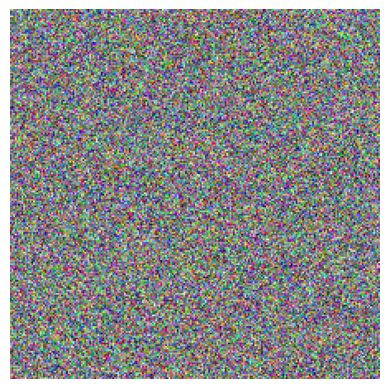

Epoch 100 loss=127.277


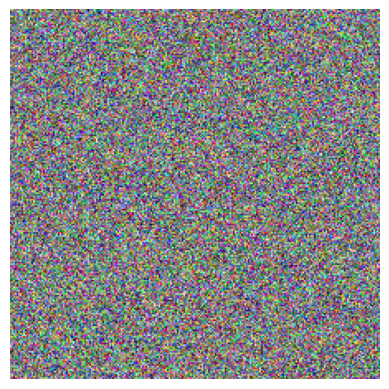

Epoch 200 loss=115.701


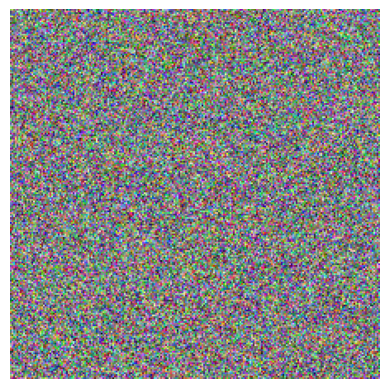

Epoch 300 loss=104.571


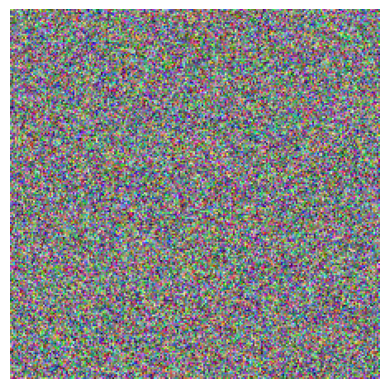

Epoch 400 loss=93.882


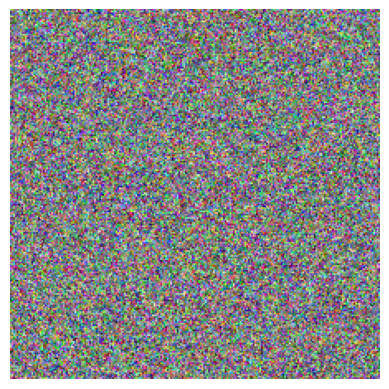

In [ ]:
import torch
def total_variation(x):
    tv_h = torch.sum(abs(x[:, :, 1:, :] - x[:, :, :-1, :]))
    tv_w = torch.sum(abs(x[:, :, :, 1:] - x[:, :, :, :-1]))
    return tv_h + tv_w

def total_loss(x, res, target):
    ce = torch.nn.functional.cross_entropy(res, target)
    tv = total_variation(x).sum()
    return 10 * ce + 0.0004 * tv

def optimize_visual(x, target, model, epochs=1000, lr=0.0007):
    x = torch.nn.Parameter(x)
    
    optimizer = torch.optim.Adam([x], lr=lr)
    for i in range(epochs):
        optimizer.zero_grad()
        res = model(x)
        loss = total_loss(x, res, target)
        loss.backward()

        # gradient normalization
        with torch.no_grad():
            grad = x.grad
            grad = grad / (grad.std() + 1e-8)
            x -= lr * grad
            x.clamp_(-2.0, 2.0)  # 防止爆值

        if i % 100 == 0:
            print(f"Epoch {i} loss={loss.item():.3f}")
            plt.imshow(normalize(x[0]).detach().cpu().permute(1,2,0))
            plt.axis('off')
            plt.show()

    return x

x = (torch.randn((1, 3, 224, 224), requires_grad=True) ).to("cuda")
target = torch.tensor([284]).to("cuda")
optimize_visual(x,target, model)

Predicted class: 284 (Siamese cat, Siamese)
Probability of predicted class = 1.0000


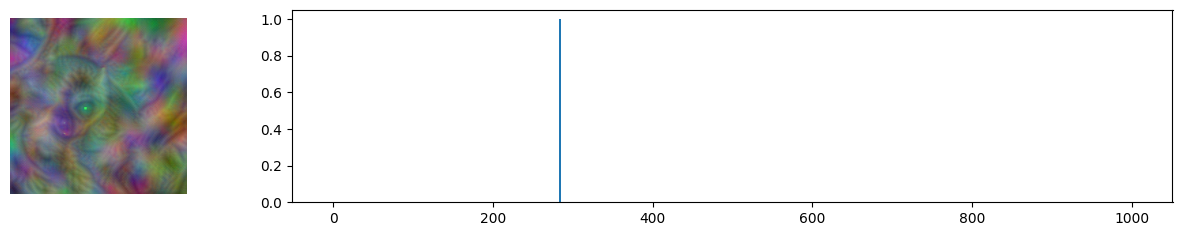

In [67]:
plot_result(x)

In [ ]:
x = torch.randn((1, 3, 224, 224), requires_grad=True)
def total_variation(x):
    """
    PyTorch version equivalent to tf.image.total_variation
    x: Tensor (B, C, H, W)
    return: Tensor of shape [B], total variation per image
    """
    # (B, C, H, W) -> (B, H, W, C)
    x = x.permute(0, 2, 3, 1)

    pixel_dif1 = x[:, 1:, :, :] - x[:, :-1, :, :]
    pixel_dif2 = x[:, :, 1:, :] - x[:, :, :-1, :]

    tv_h = torch.sum(torch.abs(pixel_dif1), dim=(1, 2, 3))
    tv_w = torch.sum(torch.abs(pixel_dif2), dim=(1, 2, 3))

    return tv_h + tv_w  # shape: [B]
def total_loss(x, res, target):
    criterion = torch.nn.CrossEntropyLoss()
    ce = criterion(res, target)
    tv = total_variation(x).sum()  # 对 batch 求和，得到标量
    return 10 * ce + 0.005 * tv

# def optimize1(x, target, epochs=1000, show_every=None, loss_fn=total_loss, lr=1):
#     # ✅ 确保 x 可训练
#     x = x.clone().detach().requires_grad_(True)
    
    
#     if show_every is None:
#         show_every = max(1, epochs // 50)

#     for i in range(epochs):
#         # 前向传播
#         outputs = model(x)
#         loss = loss_fn(x, outputs, target)

#         # 反向传播
#         loss.backward()

#         # ✅ 模仿 TensorFlow: x.assign_sub(lr * grads)
#         with torch.no_grad():
#             x -= lr * x.grad

#         # 清零梯度
#         x.grad.zero_()

#         # 可视化
#         if i % show_every == 0:
#             clear_output(wait=True)
#             print(f"Epoch: {i}, loss: {loss.item():.4f}")
#             plt.imshow(normalize(x[0]).detach().cpu().permute(1, 2, 0))
#             plt.axis("off")
#             plt.show()

#     return x.detach()


# optimize1(x,target,loss_fn=total_loss)

这是我们神经网络理想的猫的图像，我们也可以看到一些熟悉的特征，比如眼睛和耳朵。它们有很多，这使得神经网络更加确信这是一只猫。


Predicted class: 418 (ballpoint, ballpoint pen, ballpen, Biro)
Probability of predicted class = 0.0192


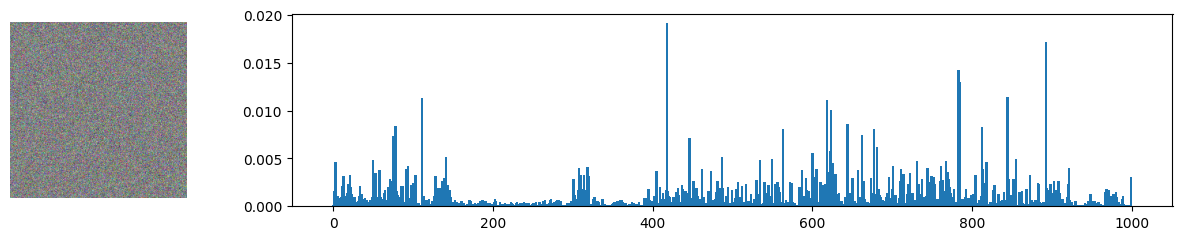

In [33]:
plot_result(x)

让我们看看 VGG 对其他一些对象的表现如何：


Epoch: 900, loss: [29.59]


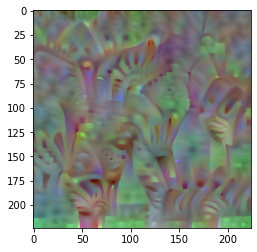

In [8]:
x = tf.Variable(tf.random.normal((1,224,224,3)))
optimize(x,[340],loss_fn=total_loss) # zebra

## 对抗攻击

由于*理想猫*图像可能看起来像随机噪声，这表明我们或许可以稍微调整任何图像，使其类别发生变化。让我们稍微实验一下这个想法。我们将从一张狗的图像开始：


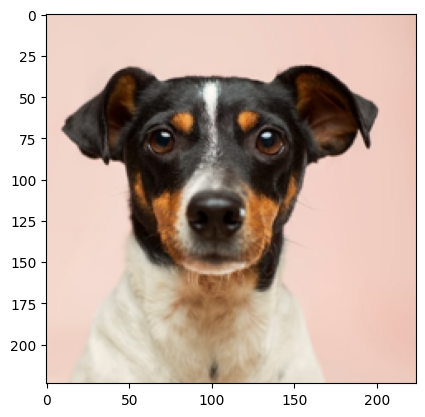

In [5]:
img = Image.open('./dog-from-unsplash.jpg')
img = img.crop((200,20,600,420)).resize((224,224))
img = np.array(img)
plt.imshow(img)

我们可以看到这张图片显然被识别为一只狗：


In [6]:
# 正确的 PyTorch 代码
processed_img = img.to(torch.float32).unsqueeze(0)
plot_result(torch.unsqueeze(torch.tensor(img), dim=0))

AttributeError: 'numpy.ndarray' object has no attribute 'to'

现在，我们将以此图像为起点，并尝试将其优化成一只猫：


Epoch 0 loss=191.836


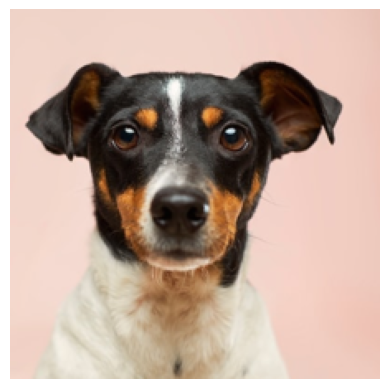

Epoch 20 loss=24.895


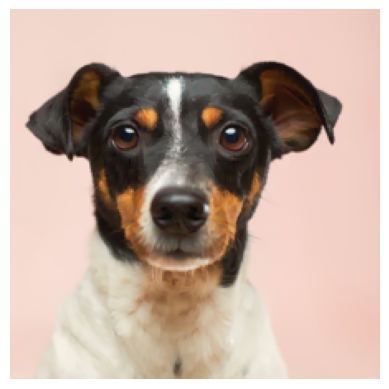

Epoch 40 loss=21.842


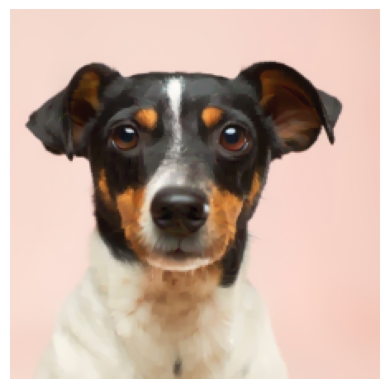

Epoch 60 loss=20.206


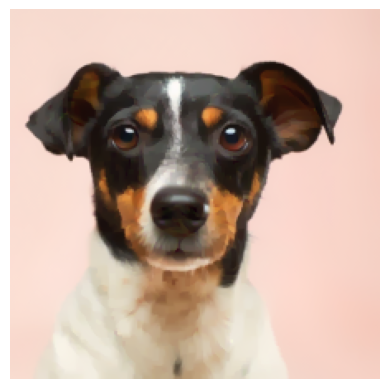

Epoch 80 loss=19.091


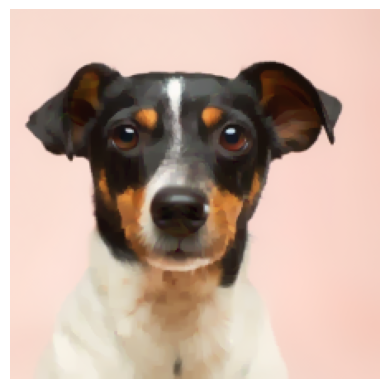

Epoch 100 loss=18.251


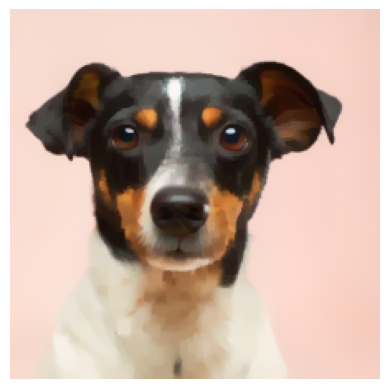

Epoch 120 loss=17.583


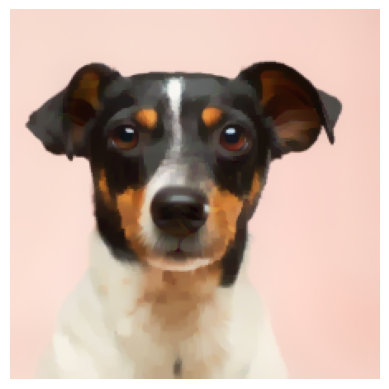

Epoch 140 loss=17.035


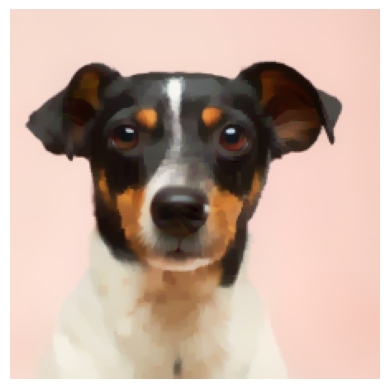

Epoch 160 loss=16.574


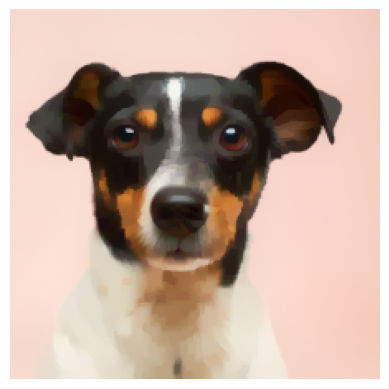

Epoch 180 loss=16.172


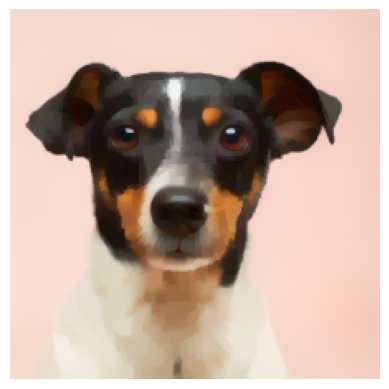

Parameter containing:
tensor([[[[0.9346, 0.9360, 0.9342,  ..., 0.9142, 0.9125, 0.9127],
          [0.9353, 0.9341, 0.9349,  ..., 0.9123, 0.9136, 0.9115],
          [0.9339, 0.9350, 0.9329,  ..., 0.9141, 0.9118, 0.9130],
          ...,
          [0.9410, 0.9412, 0.9392,  ..., 0.9323, 0.9343, 0.9327],
          [0.9417, 0.9409, 0.9414,  ..., 0.9344, 0.9336, 0.9344],
          [0.9416, 0.9417, 0.9409,  ..., 0.9339, 0.9347, 0.9339]],

         [[0.8299, 0.8310, 0.8289,  ..., 0.7668, 0.7666, 0.7668],
          [0.8308, 0.8293, 0.8306,  ..., 0.7676, 0.7659, 0.7662],
          [0.8297, 0.8304, 0.8279,  ..., 0.7670, 0.7673, 0.7648],
          ...,
          [0.8293, 0.8281, 0.8297,  ..., 0.7863, 0.7845, 0.7844],
          [0.8289, 0.8306, 0.8291,  ..., 0.7854, 0.7861, 0.7844],
          [0.8302, 0.8290, 0.8305,  ..., 0.7872, 0.7852, 0.7858]],

         [[0.7842, 0.7837, 0.7839,  ..., 0.7211, 0.7217, 0.7202],
          [0.7842, 0.7861, 0.7843,  ..., 0.7225, 0.7197, 0.7210],
          [0.7856, 0

In [49]:
img_pil = Image.open("./dog-from-unsplash.jpg")

# 裁剪 + 缩放（直接调用方法）
img_cropped_resized = img_pil.crop((200, 20, 600, 420)).resize((224, 224))

# 转 NumPy 数组或 PyTorch 张量（后续步骤同上）
img_final = np.array(img_cropped_resized)
# 转换为 PyTorch 格式: [1, 3, H, W]
x = torch.tensor(img_final, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0) / 255.0
device="cuda"
model = model.to(device)
x = x.to(device)
target = torch.tensor([84], device=device) 
# 开启梯度
x.requires_grad_(True)
optimize_visual(x,target,model)

In [112]:
torch.cuda.empty_cache()

所以，从 VGG 网络的角度来看，上面的这张图片是一只完美的猫！

## 使用 ResNet 进行实验

现在让我们看看这张图片是如何被另一个模型（比如 ResNet）分类的：


In [13]:
model = keras.applications.ResNet50(weights='imagenet',include_top=True)

由于我们将 `model` 用作全局变量，从现在开始所有函数将使用 ResNet 而不是 VGG


Predicted class: 84 (peacock)
Probability of predicted class = 0.9969


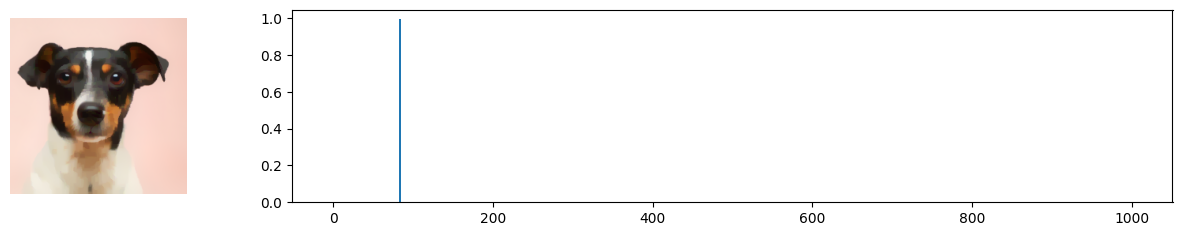

In [50]:
plot_result(x)

显然，结果非常不同。这是可以预料的，因为在针对猫进行优化时，我们考虑了VGG网络的特性、它的低级滤波器等因素。由于ResNet具有不同的滤波器，因此它给出了不同的结果。这让我们产生了一个想法：我们可以通过使用不同模型的集成来保护自己免受对抗性攻击。

让我们看看在ResNet中理想的斑马是什么样子的：


Epoch: 450, loss: [46.166]


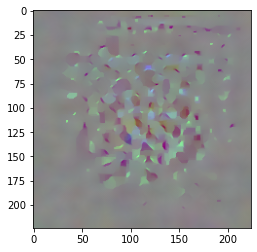

In [15]:
x = tf.Variable(tf.random.normal((1,224,224,3)))
optimize(x,target=[340],epochs=500,loss_fn=total_loss)

Predicted class: 340 (zebra)
Probability of predicted class = 0.8876020312309265


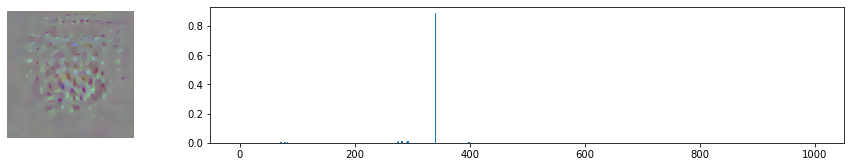

In [16]:
plot_result(x)

这幅图截然不同，告诉我们神经网络的架构可能在其识别物体的方式中起着相当重要的作用。

> **任务**: 尝试对 ResNet 进行对抗攻击，并比较结果。

## 使用不同的优化器

在我们的例子中，我们一直在使用最简单的优化技术——梯度下降。然而，Keras 框架包含了不同的内置[优化器](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers)，我们可以用它们来代替梯度下降。这只需要对我们的代码进行很小的改动——我们将用优化器的 `apply_gradients` 函数替换调整输入图像 `x.assign_sub(eta*grads)` 的部分：


Epoch: 900, loss: [41.451]


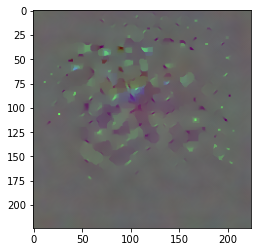

In [17]:
def optimize(x,target,epochs=1000,show_every=None,loss_fn=cross_entropy_loss,optimizer=keras.optimizers.SGD(learning_rate=1)):
    if show_every is None:
        show_every = epochs // 10
    for i in range(epochs):
        with tf.GradientTape() as t:
            res = model(x)
            loss = loss_fn(target,res)
            grads = t.gradient(loss,x)
            optimizer.apply_gradients([(grads,x)])
            if i%show_every == 0:
                clear_output(wait=True)
                print(f"Epoch: {i}, loss: {loss}")
                plt.imshow(normalize(x[0]))
                plt.show()

x = tf.Variable(tf.random.normal((1,224,224,3)))

optimize(x,[898],loss_fn=total_loss) # water bottle

## 结论

我们通过使用梯度下降优化调整输入图像（而非权重），成功在预训练的CNN中可视化了理想的猫的图像（以及其他任何对象）。获得有意义图像的主要技巧是使用变化损失作为附加损失函数，这使得图像看起来更加平滑。



---

**免责声明**：  
本文档使用AI翻译服务 [Co-op Translator](https://github.com/Azure/co-op-translator) 进行翻译。尽管我们努力确保翻译的准确性，但请注意，自动翻译可能包含错误或不准确之处。原始语言的文档应被视为权威来源。对于关键信息，建议使用专业人工翻译。我们不对因使用此翻译而产生的任何误解或误读承担责任。
